In [7]:
import pandas as pd #
import numpy as np
from joblib import load
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
import matplotlib.pyplot as plt
import seaborn as sns

crit_thresh = -0.097692
warn_thresh = -0.045423

# Load Isolation Forest model and scaler
scaler = load('/content/iso_scaler2.joblib')
iso_model = load('/content/iso_model2.joblib')

# Load datasets
#df_val = pd.read_csv("./data/validate.csv")
df_val = pd.read_csv("/content/monitoring_data_2025-11-18_17-55-48.csv")
#df_val = df_val[df_val['devID'] == 103]
#df1 = pd.read_csv("./data/dev101_prepared.csv")
#df2 = pd.read_csv("./data/dev102_prepared.csv")

#df_val = pd.concat([df1, df2], ignore_index=True)
df_val

,Timestamp,device,devID,temp,humi,soil,rain,geo,ISO Risk,LSTM Risk,RF Risk,label
0,11/18/2025 17:55,109,Node 109,23.20,98.40,44.7,0.00,0.47,0,0,0,NaN
1,11/18/2025 17:54,109,Node 109,23.20,98.40,44.7,0.00,0.56,0,0,0,NaN
2,11/18/2025 17:54,109,Node 109,23.25,98.45,44.7,0.00,0.55,0,0,0,NaN
3,11/18/2025 17:53,109,Node 109,23.30,98.50,44.7,0.00,0.53,0,0,0,NaN
4,11/18/2025 17:52,109,Node 109,23.30,98.50,44.7,0.00,2.04,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2066,11/17/2025 12:16,109,Node 109,24.50,96.90,39.4,7.82,24.25,2,0,2,critical
2067,11/4/2025 4:43,109,Node 109,34.60,59.40,27.1,0.00,0.41,0,0,0,NaN
2068,11/4/2025 4:42,109,Node 109,34.50,60.05,27.1,0.00,2.01,0,0,0,NaN
2069,11/4/2025 4:40,109,Node 109,34.40,62.20,27.1,0.00,0.30,0,0,0,NaN


In [8]:
df = df_val.sort_values('Timestamp').reset_index(drop=True)

In [9]:
df_val

,Timestamp,device,devID,temp,humi,soil,rain,geo,ISO Risk,LSTM Risk,RF Risk,label
0,11/18/2025 17:55,109,Node 109,23.20,98.40,44.7,0.00,0.47,0,0,0,NaN
1,11/18/2025 17:54,109,Node 109,23.20,98.40,44.7,0.00,0.56,0,0,0,NaN
2,11/18/2025 17:54,109,Node 109,23.25,98.45,44.7,0.00,0.55,0,0,0,NaN
3,11/18/2025 17:53,109,Node 109,23.30,98.50,44.7,0.00,0.53,0,0,0,NaN
4,11/18/2025 17:52,109,Node 109,23.30,98.50,44.7,0.00,2.04,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2066,11/17/2025 12:16,109,Node 109,24.50,96.90,39.4,7.82,24.25,2,0,2,critical
2067,11/4/2025 4:43,109,Node 109,34.60,59.40,27.1,0.00,0.41,0,0,0,NaN
2068,11/4/2025 4:42,109,Node 109,34.50,60.05,27.1,0.00,2.01,0,0,0,NaN
2069,11/4/2025 4:40,109,Node 109,34.40,62.20,27.1,0.00,0.30,0,0,0,NaN


In [10]:
#df_val  = pd.concat([df1, df2], ignore_index=True)
df_val.describe()

,device,temp,humi,soil,rain,geo,ISO Risk,LSTM Risk,RF Risk
count,2071.0,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000
mean,109.0,23.854611,98.202342,43.721101,2.001569,5.152907,0.282472,0.231772,0.385804
std,0.0,0.615262,1.656387,2.972200,5.101293,7.986658,0.638444,0.613358,0.660384
min,109.0,22.800000,59.400000,27.100000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,109.0,23.600000,98.100000,41.200000,0.000000,0.390000,0.000000,0.000000,0.000000
50%,109.0,23.900000,98.300000,42.300000,0.280000,0.580000,0.000000,0.000000,0.000000
75%,109.0,24.000000,98.600000,45.800000,1.120000,5.750000,0.000000,0.000000,1.000000
max,109.0,34.600000,99.000000,51.800000,31.990000,32.000000,2.000000,2.000000,2.000000


## Threshold

In [11]:
#def rule_based_risk(row):
#   score = 0
#
#   # Rainfall (mm/h)
#   if row['rain'] > 25:
#       score += 2
#   elif row['rain'] > 10:
#       score += 1
#
#   # Soil moisture (%)
#   if row['soil'] > 60:
#       score += 2
#   elif row['soil'] > 45:
#       score += 1
#
#   # Temperature (°C)
#   if row['temp'] < 27:
#       score += 2
#   elif row['temp'] < 32:
#       score += 1
#
#   # Humidity (%)
#   if row['humi'] > 80:
#       score += 2
#   elif row['humi'] > 65:
#       score += 1
#
#   # Geophone (Hz)
#   if row['geo'] > 25:
#       score += 1
#   elif row['geo'] > 10:
#       score += 0.5
#
#   if score >= 6:
#       return "Critical"
#   elif score >= 3:
#       return "Warning"
#   else:
#       return "Normal"
#
#feature_cols = ['soil', 'rain', 'temp', 'humi', 'geo']
#X_val = df_val[feature_cols].values
#X_val_scaled = scaler.transform(X_val)
#
#df_val['anomaly_score'] = iso_model.decision_function(X_val_scaled)
#
#crit_thresh = np.percentile(df_val['anomaly_score'], 0.5)
#warn_thresh = np.percentile(df_val['anomaly_score'], 5)
#
#def model_based_risk(score):
#   if score < crit_thresh:
#       return "Critical"
#   elif score < warn_thresh:
#       return "Warning"
#   else:
#       return "Normal"
#
#df_val['model_risk'] = df_val['anomaly_score'].apply(model_based_risk)
#df_val['rule_risk'] = df_val.apply(rule_based_risk, axis=1)
#
#risk_levels = {'Normal': 0, 'Warning': 1, 'Critical': 2}
#
#def combine_weighted_risks(model_risk, rule_risk, w_model=0.6, w_rule=0.4):
#   score = w_model * risk_levels[model_risk] + w_rule * risk_levels[rule_risk]
#
#   if score >= 1.5:
#       return "Critical"
#   elif score >= 0.5:
#       return "Warning"
#   else:
#       return "Normal"
#
#df_val['predicted_risk'] = df_val.apply(
#    lambda row: combine_weighted_risks(row['model_risk'], row['rule_risk']),
#    axis=1
#)
#
#print(df_val[['soil', 'rain', 'temp', 'humi', 'geo',
#              'anomaly_score', 'model_risk', 'rule_risk', 'predicted_risk']].head())

In [12]:
# สร้าง features
feature_cols = ['soil', 'rain', 'temp', 'humi', 'geo']
X_val = df_val[feature_cols].values
X_val_scaled = scaler.transform(X_val)

# คำนวณ anomaly score และจัดระดับความเสี่ยง
df_val['anomaly_score'] = iso_model.decision_function(X_val_scaled)


#crit_thresh = np.percentile(df_val['anomaly_score'], 0.25)
#warn_thresh = np.percentile(df_val['anomaly_score'], 0.75)
#crit_thresh = -0.094870
#warn_thresh = -0.042534

def classify_risk(score):
    if score < crit_thresh:
        return "Critical"
    elif score < warn_thresh:
        return "Warning"
    else:
        return "Normal"

df_val['predicted_risk'] = df_val['anomaly_score'].apply(classify_risk)

In [13]:
#print("crit_thresh:", np.percentile(df_val['anomaly_score'], 0.433))
#print("warn_thresh:", np.percentile(df_val['anomaly_score'], 2.226))

In [14]:
critical_group = df_val[df_val['anomaly_score'] < crit_thresh]
print("critical_group")
print(critical_group[feature_cols].describe())

critical_group
             soil        rain        temp        humi         geo
count  212.000000  212.000000  212.000000  212.000000  212.000000
mean    47.398113   14.221792   23.526887   98.162972   16.897217
std      3.067912    8.721464    0.454372    0.640301    9.160722
min     39.400000    0.560000   22.800000   96.900000    0.240000
25%     45.787500    7.820000   23.300000   97.637500   14.252500
50%     48.425000   11.320000   23.500000   98.500000   18.640000
75%     50.100000   20.950000   23.762500   98.700000   22.937500
max     51.800000   31.990000   24.700000   98.900000   32.000000


In [15]:
warn_group = df_val[(df_val['anomaly_score'] < warn_thresh) & (df_val['anomaly_score'] >= crit_thresh) ]
print("warn_group")
print(warn_group[feature_cols].describe())

warn_group
             soil        rain        temp        humi         geo
count  161.000000  161.000000  161.000000  161.000000  161.000000
mean    46.283851    3.287578   23.528571   98.455901   16.056646
std      3.046692    2.207805    0.454757    0.419389    9.791522
min     39.700000    0.000000   22.900000   96.900000    0.000000
25%     44.150000    1.400000   23.200000   98.400000    9.270000
50%     48.200000    3.350000   23.500000   98.600000   17.800000
75%     48.400000    4.470000   23.800000   98.700000   22.560000
max     49.200000    8.660000   24.800000   98.900000   32.000000


In [16]:
normal_group = df_val[df_val['anomaly_score'] >= warn_thresh]
print("normal_group")
print(normal_group[feature_cols].describe())

normal_group
              soil         rain         temp         humi          geo
count  1698.000000  1698.000000  1698.000000  1698.000000  1698.000000
mean     43.019022     0.353905    23.926443    98.183216     2.652733
std       2.434106     0.544886     0.622831     1.808990     4.854716
min      27.100000     0.000000    22.900000    59.400000     0.210000
25%      41.200000     0.000000    23.700000    98.100000     0.370000
50%      42.050000     0.000000    23.900000    98.300000     0.500000
75%      44.900000     0.560000    24.000000    98.500000     2.100000
max      49.900000     3.350000    34.600000    99.000000    29.320000


/tmp/ipython-input-2053204387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_val, x='predicted_risk', order=['Normal', 'Warning', 'Critical'], palette='Set2')


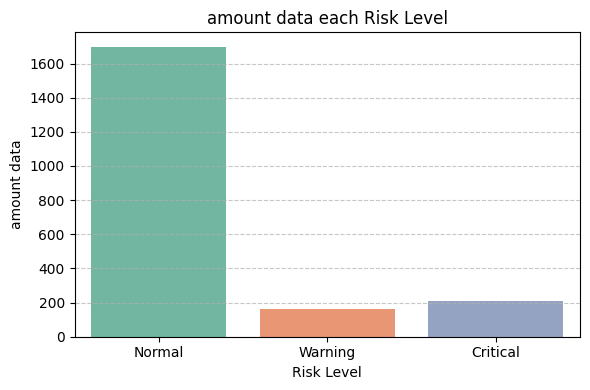

In [17]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df_val, x='predicted_risk', order=['Normal', 'Warning', 'Critical'], palette='Set2')

plt.title('amount data each Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('amount data')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Distribution of Anomaly Scores

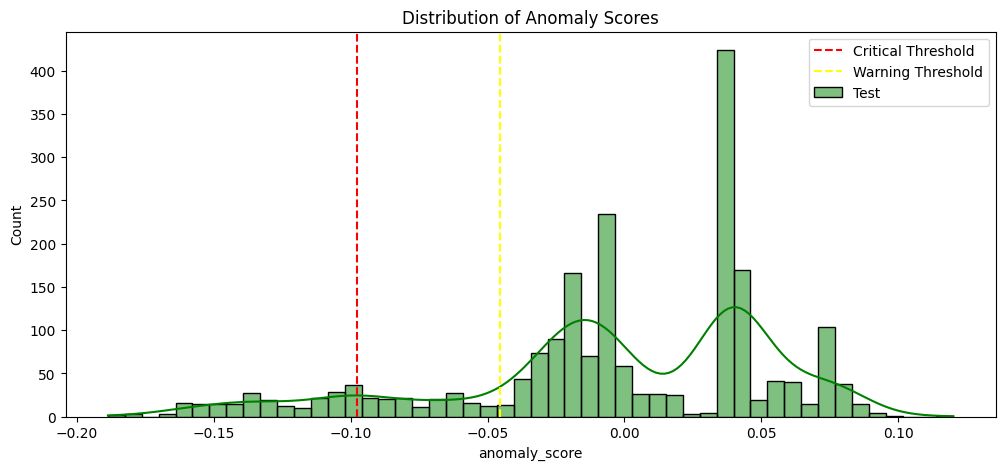

In [18]:
plt.figure(figsize=(12,5))
sns.histplot(df_val['anomaly_score'], bins=50, kde=True, color='green', label='Test')
plt.axvline(crit_thresh, color='red', linestyle='--', label='Critical Threshold')
plt.axvline(warn_thresh, color='yellow', linestyle='--', label='Warning Threshold')
plt.legend()
plt.title('Distribution of Anomaly Scores')
plt.show()



## Z-score Outlier

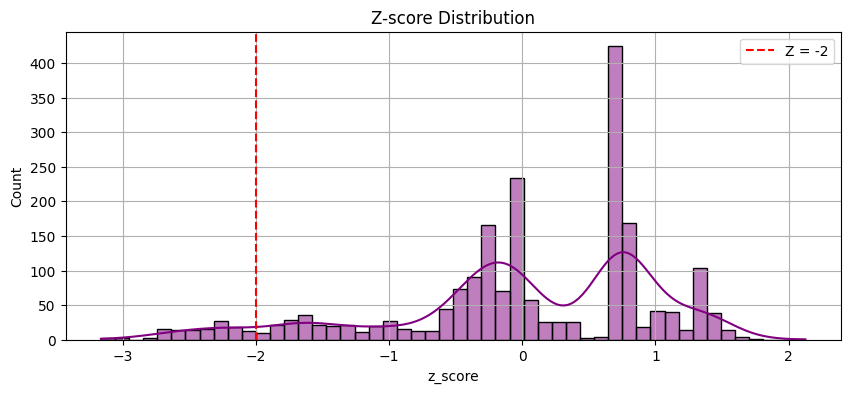

In [19]:
# ==== Z-score Outlier ====

mean_score = df_val['anomaly_score'].mean()
std_score = df_val['anomaly_score'].std()
df_val['z_score'] = (df_val['anomaly_score'] - mean_score) / std_score
df_val['z_outlier'] = df_val['z_score'].apply(lambda z: 'Anomaly' if z < -2 else 'Normal')

plt.figure(figsize=(10,4))
sns.histplot(df_val['z_score'], kde=True, bins=50, color='purple')
plt.axvline(-2, color='red', linestyle='--', label='Z = -2')
plt.title("Z-score Distribution")
plt.legend()
plt.grid(True)
plt.show()

## Mahalanobis Distance

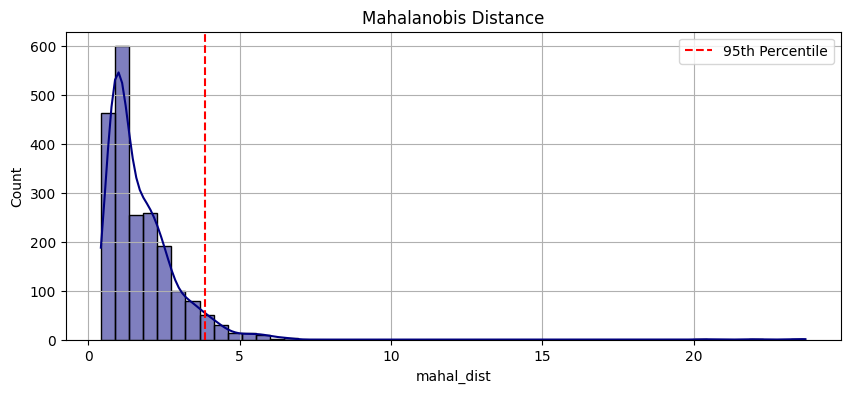

In [20]:
mean_vec = np.mean(X_val_scaled, axis=0)
cov_matrix = np.cov(X_val_scaled, rowvar=False)
inv_covmat = np.linalg.inv(cov_matrix)

df_val['mahal_dist'] = [mahalanobis(x, mean_vec, inv_covmat) for x in X_val_scaled]
mahal_thresh = np.percentile(df_val['mahal_dist'], 95)
df_val['mahal_outlier'] = df_val['mahal_dist'].apply(lambda d: 'Anomaly' if d > mahal_thresh else 'Normal')

plt.figure(figsize=(10,4))
sns.histplot(df_val['mahal_dist'], bins=50, kde=True, color='navy')
plt.axvline(mahal_thresh, color='red', linestyle='--', label='95th Percentile')
plt.title("Mahalanobis Distance")
plt.legend()
plt.grid(True)
plt.show()

## Percentile Threshold 5%

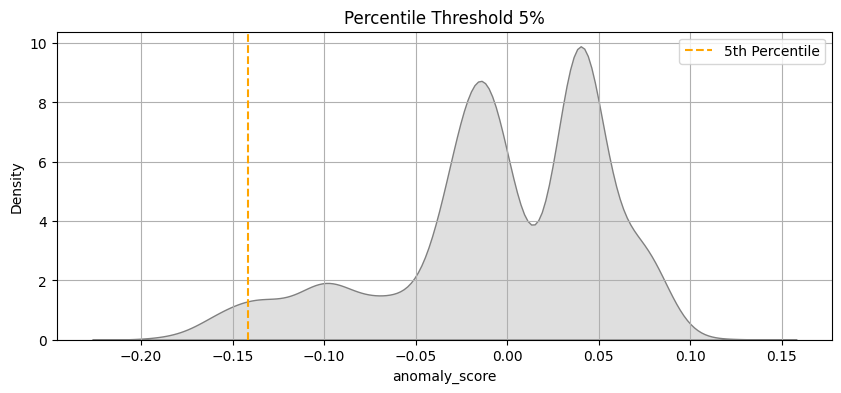

In [21]:
percentile = np.percentile(df_val['anomaly_score'], 3)
df_val['percentile_outlier'] = df_val['anomaly_score'].apply(lambda s: 'Anomaly' if s < percentile else 'Normal')

plt.figure(figsize=(10,4))
sns.kdeplot(df_val['anomaly_score'], fill=True, color='gray')
plt.axvline(percentile, color='orange', linestyle='--', label='5th Percentile')
plt.title("Percentile Threshold 5%")
plt.legend()
plt.grid(True)
plt.show()

## PCA

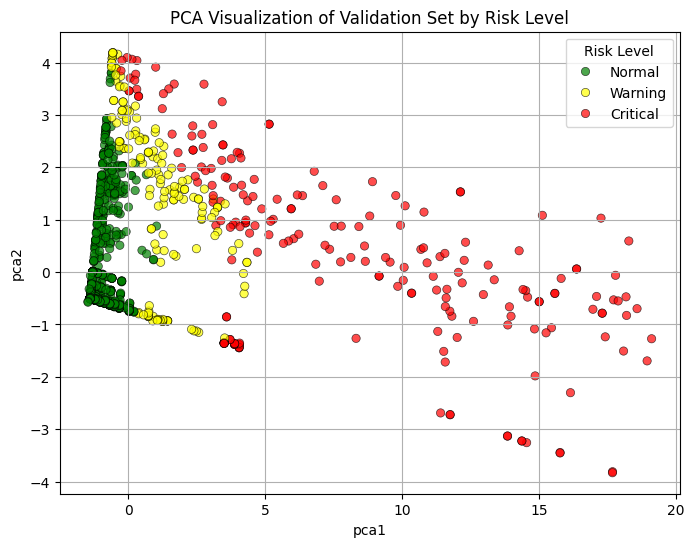

In [22]:
# Fit PCA
pca = PCA(n_components=2)
X_val_pca = pca.fit_transform(X_val_scaled)

# เพิ่มค่า PCA กลับเข้า df_val
df_val['pca1'] = X_val_pca[:, 0]
df_val['pca2'] = X_val_pca[:, 1]

# Map สีแบบกำหนดเอง
custom_palette = {
    'Normal': 'green',
    'Warning': 'yellow',
    'Critical': 'red'
}

# วาดกราฟ
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_val,
    x='pca1', y='pca2',
    hue='predicted_risk',
    palette=custom_palette,
    alpha=0.7,
    edgecolor='black'
)
plt.title('PCA Visualization of Validation Set by Risk Level')
plt.grid(True)
plt.legend(title='Risk Level')
plt.show()

In [23]:
explained_var = pca.explained_variance_ratio_
print(f"PCA explain {explained_var[0]*100:.2f}% and {explained_var[1]*100:.2f}% of data")


PCA explain 89.53% and 9.61% of data


In [24]:
# ดูว่าแต่ละ feature มีน้ำหนักกับแต่ละ principal component เท่าไหร่ x=PC1 y=PC2
pca_df = pd.DataFrame(pca.components_, columns=feature_cols, index=["PC1", "PC2"])
print(pca_df.T.sort_values("PC1", ascending=False))  # เรียงตามผลต่อแกน X


           PC1       PC2
rain  0.984485 -0.172539
geo   0.171550  0.984666
soil  0.033822  0.023478
humi  0.000654  0.003720
temp -0.014676 -0.009950


## Summary Statistics

In [25]:
print("\n== Z-score Outlier ==")
print(df_val['z_outlier'].value_counts())


== Z-score Outlier ==
z_outlier
Normal     1946
Anomaly     125
Name: count, dtype: int64


In [26]:
print("\n== Percentile Outlier ==")
print(f"5th Percentile Threshold: {percentile:.4f}")
print(df_val['percentile_outlier'].value_counts())


== Percentile Outlier ==
5th Percentile Threshold: -0.1415
percentile_outlier
Normal     2008
Anomaly      63
Name: count, dtype: int64


In [27]:
print("\n== Mahalanobis Outlier ==")
print(f"95th Percentile of Mahalanobis Distance: {mahal_thresh:.2f}")
print(df_val['mahal_outlier'].value_counts())


== Mahalanobis Outlier ==
95th Percentile of Mahalanobis Distance: 3.85
mahal_outlier
Normal     1967
Anomaly     104
Name: count, dtype: int64


In [28]:
overlap = df_val[
    (df_val['z_outlier'] == 'Anomaly') &
    (df_val['percentile_outlier'] == 'Anomaly') &
    (df_val['mahal_outlier'] == 'Anomaly')
]
print(f"Anomalies detected by ALL 3 methods: {len(overlap)}")


Anomalies detected by ALL 3 methods: 42


In [29]:
df_val['combined_outlier'] = df_val.apply(
    lambda row: (
        row['z_outlier'] == 'Anomaly' or
        row['percentile_outlier'] == 'Anomaly' or
        row['mahal_outlier'] == 'Anomaly'
    ),
    axis=1
)

print("\n== Combined Outlier ==")
print(df_val['combined_outlier'].value_counts())


== Combined Outlier ==
combined_outlier
False    1903
True      168
Name: count, dtype: int64


In [30]:
print("\n== Mean Feature Values by Risk Level ==")
print(df_val.groupby('predicted_risk')[feature_cols].mean())


== Mean Feature Values by Risk Level ==
                     soil       rain       temp       humi        geo
predicted_risk                                                       
Critical        47.398113  14.221792  23.526887  98.162972  16.897217
Normal          43.019022   0.353905  23.926443  98.183216   2.652733
Warning         46.283851   3.287578  23.528571  98.455901  16.056646


In [31]:
print("\n== Risk Level ==")
print(df_val['predicted_risk'].value_counts())


== Risk Level ==
predicted_risk
Normal      1698
Critical     212
Warning      161
Name: count, dtype: int64


In [32]:
def risk_from_combined(row):
    if row['combined_outlier']:
        if row['anomaly_score'] < crit_thresh:
            return 'Critical'
        elif row['anomaly_score'] < warn_thresh:
            return 'Warning'
        else:
            return 'Warning'
    return 'Normal'

df_val['risk_level_final'] = df_val.apply(risk_from_combined, axis=1)
print("\n== risk level final ==")
print(df_val['risk_level_final'].value_counts())


== risk level final ==
risk_level_final
Normal      1903
Critical     130
Warning       38
Name: count, dtype: int64


In [33]:
print("\n== Risk final Proportion ==")
print("Validation:", df_val['risk_level_final'].value_counts(normalize=True))


== Risk final Proportion ==
Validation: risk_level_final
Normal      0.918880
Critical    0.062772
Warning     0.018349
Name: proportion, dtype: float64


In [34]:
print("\n== Risk Proportion ==")
print("Validation:", df_val['predicted_risk'].value_counts(normalize=True))


== Risk Proportion ==
Validation: predicted_risk
Normal      0.819894
Critical    0.102366
Warning     0.077740
Name: proportion, dtype: float64


##  Signal-to-Noise Ratio (SNR)

In [35]:
def compute_snr(signal):
    mean_signal = np.mean(signal)
    std_signal = np.std(signal)
    return mean_signal / std_signal if std_signal != 0 else 0

for col in feature_cols:
    snr = compute_snr(df_val[col])
    print(f"SNR of {col}: {snr:.2f}")


SNR of soil: 14.71
SNR of rain: 0.39
SNR of temp: 38.78
SNR of humi: 59.30
SNR of geo: 0.65


In [36]:
for col in feature_cols:
    normal_snr = compute_snr(df_val[df_val['predicted_risk'] == 'Normal'][col])
    anomaly_snr = compute_snr(df_val[df_val['predicted_risk'] != 'Normal'][col])
    print(f"{col}: Normal SNR={normal_snr:.2f}, Anomaly SNR={anomaly_snr:.2f}")


soil: Normal SNR=17.68, Anomaly SNR=15.13
rain: Normal SNR=0.65, Anomaly SNR=1.10
temp: Normal SNR=38.43, Anomaly SNR=51.90
humi: Normal SNR=54.29, Anomaly SNR=171.51
geo: Normal SNR=0.55, Anomaly SNR=1.75


## Mean Absolute Error (MAE)

In [37]:
df_val['Timestamp'] = pd.to_datetime(df_val['Timestamp'])
interval = df_val['Timestamp'].diff().median()
print(f"Sampling interval: {interval}")


Sampling interval: -1 days +23:59:00


In [38]:
window_size = int(pd.Timedelta('1H') / interval)
print(f"Rolling window size for 1 hour: {window_size}")


Rolling window size for 1 hour: -60


/tmp/ipython-input-504831528.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window_size = int(pd.Timedelta('1H') / interval)


In [39]:
interval = df_val['Timestamp'].diff().median()
window_size = int(pd.Timedelta('1H') / interval)

print(f"Using rolling window size = {window_size} for 1 hour")

for col in feature_cols:
    df_val[f'{col}_roll_mean'] = df_val[col].rolling(window=window_size, center=True).mean()
    df_val[f'{col}_mae'] = (df_val[col] - df_val[f'{col}_roll_mean']).abs()

    mae = df_val[f'{col}_mae'].mean()
    print(f"MAE for {col} (vs rolling mean): {mae:.2f}")


Using rolling window size = -60 for 1 hour


/tmp/ipython-input-2120260360.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window_size = int(pd.Timedelta('1H') / interval)


ValueError: window must be an integer 0 or greater

## Cross-Correlation

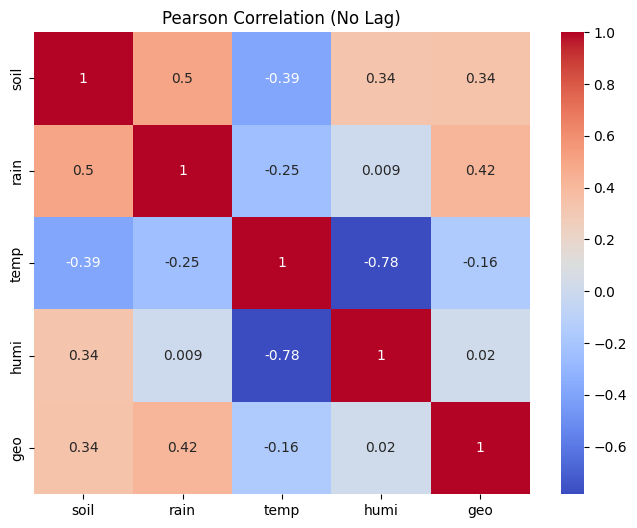

In [40]:
corr_matrix = df_val[feature_cols]
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix.corr(), annot=True, cmap='coolwarm')
plt.title("Pearson Correlation (No Lag)")
plt.show()

In [41]:
def lag_corr(x, y, max_lag=window_size*10):
    lags = []
    corrs = []
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            corr = np.corrcoef(x[:lag], y[-lag:])[0, 1]
        elif lag > 0:
            corr = np.corrcoef(x[lag:], y[:-lag])[0, 1]
        else:
            corr = np.corrcoef(x, y)[0, 1]
        lags.append(lag)
        corrs.append(corr)
    return lags, corrs


/tmp/ipython-input-1202832202.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df_val['rain'].fillna(method='ffill').values
/tmp/ipython-input-1202832202.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df_val['soil'].fillna(method='ffill').values


ValueError: attempt to get argmax of an empty sequence

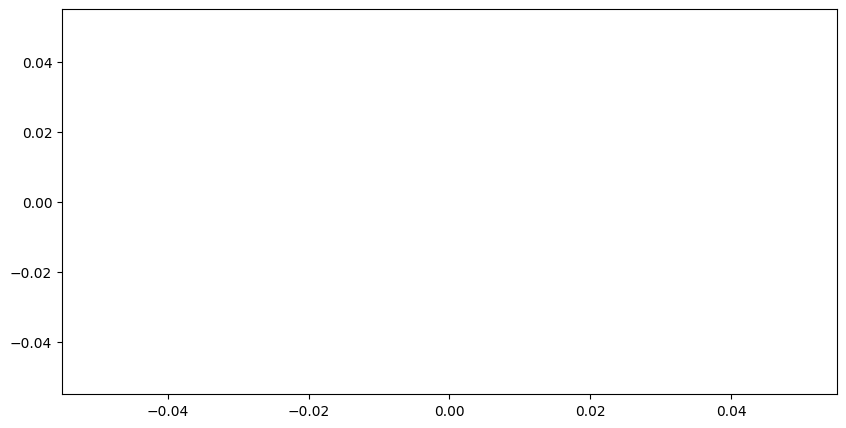

In [42]:
x = df_val['rain'].fillna(method='ffill').values
y = df_val['soil'].fillna(method='ffill').values
lags, corrs = lag_corr(x, y, max_lag=window_size*10)

plt.figure(figsize=(10, 5))
plt.plot(lags, corrs)
plt.axvline(x=np.argmax(corrs) - 60, color='green', linestyle='--', label='Max Correlation Lag')
plt.title("Manual Lag Correlation: Rain vs Soil")
plt.xlabel("Lag (timesteps)")
plt.ylabel("Correlation")
plt.grid(True)
plt.legend()
plt.show()


/tmp/ipython-input-3179048846.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x = df_val['rain'].fillna(method='ffill').values
/tmp/ipython-input-3179048846.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df_val['soil'].fillna(method='ffill').values


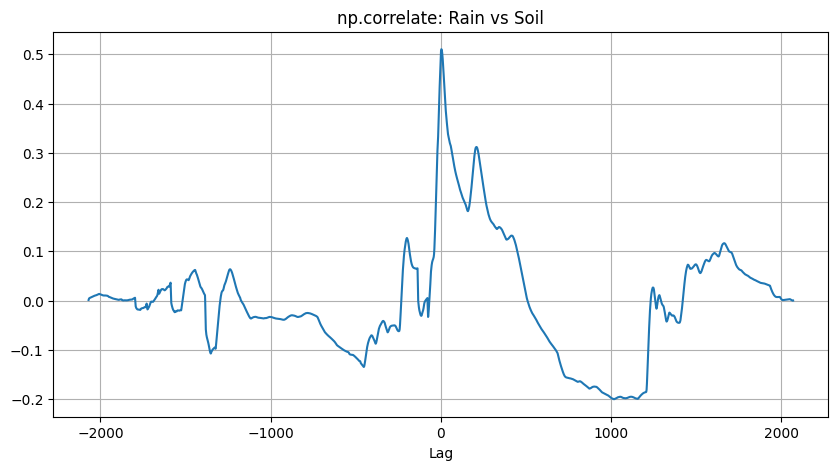

In [43]:
x = df_val['rain'].fillna(method='ffill').values
y = df_val['soil'].fillna(method='ffill').values

x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

corr = np.correlate(x, y, mode='full') / len(x)
lags = np.arange(-len(x)+1, len(x))

plt.figure(figsize=(10,5))
plt.plot(lags, corr)
plt.title("np.correlate: Rain vs Soil")
plt.xlabel("Lag")
plt.grid(True)
plt.show()


In [44]:
# ตัวอย่าง: ถ้า sampling ทุก 10 นาที → 48 จุด = 8 ชั่วโมง
df = df_val.copy()
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

rolling_corr = df['rain'].rolling(window_size*8).corr(df['soil'])

plt.figure(figsize=(12, 4))
plt.plot(df['Timestamp'], rolling_corr, color='orange')
plt.title(f"Rolling Correlation: rain vs soil (window={window_size*8})")
plt.xlabel("Timestamp")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: window must be an integer 0 or greater

## histogram

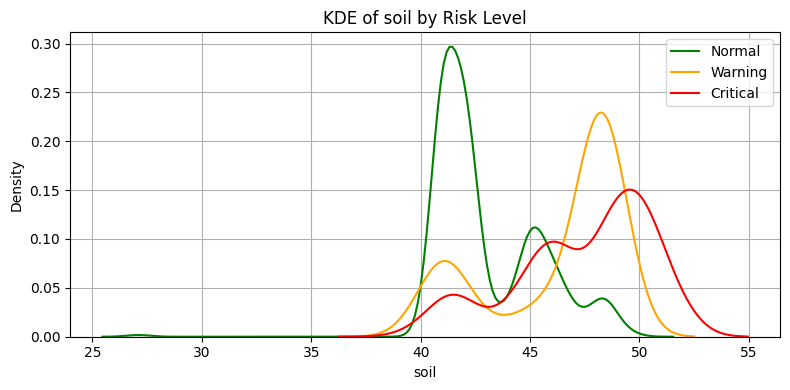

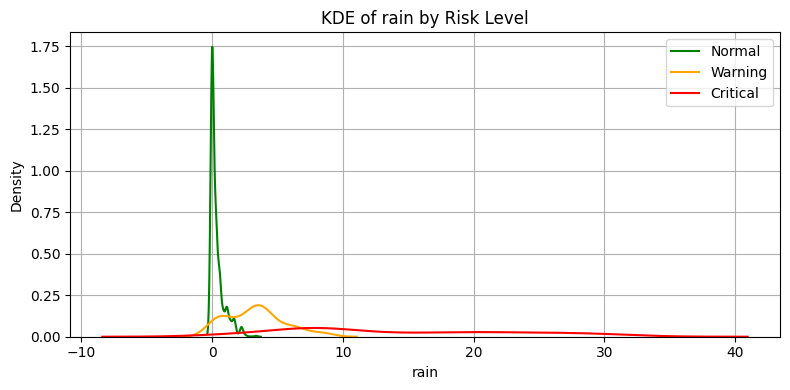

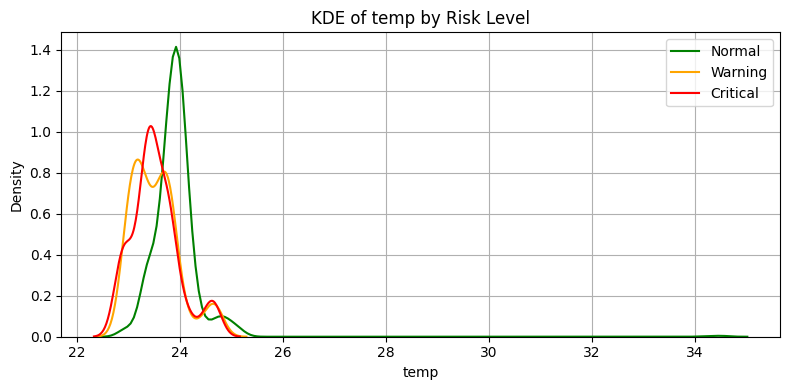

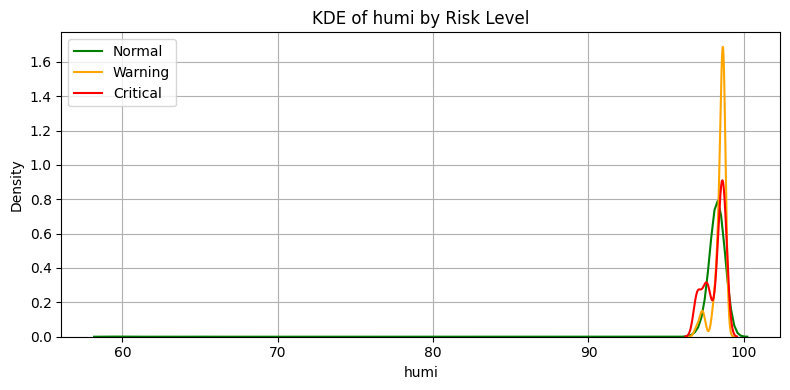

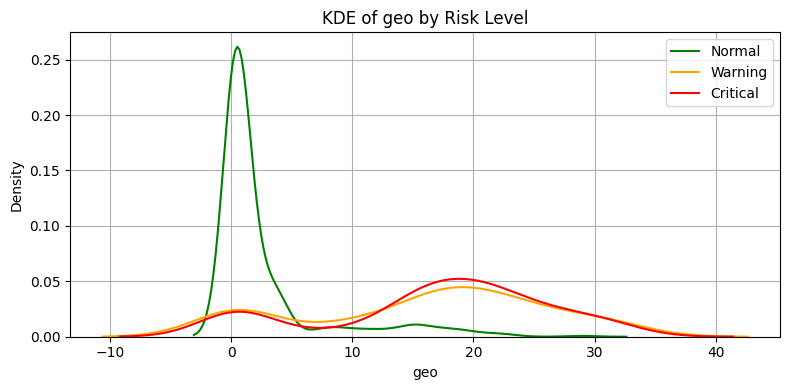

In [45]:
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df_val[df_val['predicted_risk'] == 'Normal'][col], label='Normal', color='green')
    sns.kdeplot(df_val[df_val['predicted_risk'] == 'Warning'][col], label='Warning', color='orange')
    sns.kdeplot(df_val[df_val['predicted_risk'] == 'Critical'][col], label='Critical', color='red')
    plt.title(f"KDE of {col} by Risk Level")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Box Plot feature by risk

In [ ]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(feature_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(
        x='predicted_risk',
        y=col,
        data=df_val,
        order=['Normal', 'Warning', 'Critical'],  # 🔧 fix order here
        palette='Set2'
    )
    plt.title(f'{col} by Risk Level')
plt.tight_layout()
plt.show()


## Time Series

In [46]:
df['Timestamp'].min()

Timestamp('2025-11-04 04:40:00')

In [47]:
df['Timestamp'].max()

Timestamp('2025-11-18 17:55:00')

In [48]:
if 'timestamp' in df_val.columns:
    df_val['timestamp'] = pd.to_datetime(df_val['timestamp'])
    df_val_sorted = df_val.sort_values('timestamp')

    plt.figure(figsize=(12,5))
    plt.plot(df_val_sorted['timestamp'], df_val_sorted['anomaly_score'], color='black', label='Anomaly Score')
    plt.axhline(warn_thresh, color='orange', linestyle='--', label='Warning')
    plt.axhline(crit_thresh, color='red', linestyle='--', label='Critical')
    plt.title('Anomaly Score over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

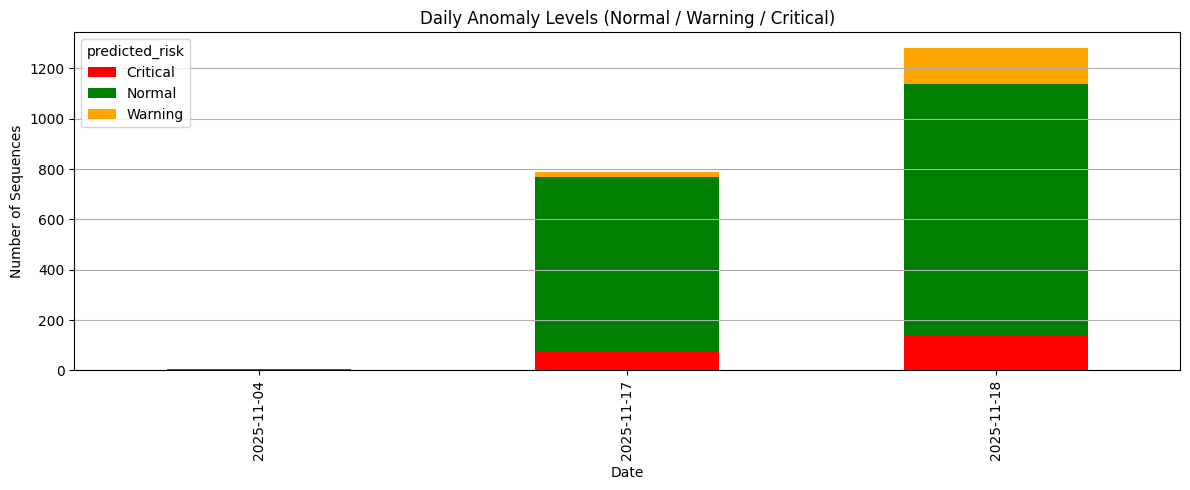

In [49]:

df_results = df_val
df_results['date'] = pd.to_datetime(df_results['Timestamp']).dt.date

risk_order = ['Critical', 'Normal', 'Warning']

alerts_per_day = df_results.groupby(['date', 'predicted_risk']).size().unstack(fill_value=0)

for risk in risk_order:
    if risk not in alerts_per_day.columns:
        alerts_per_day[risk] = 0

alerts_per_day = alerts_per_day[risk_order]

colors = ['red', 'green', 'orange']

alerts_per_day.plot(kind='bar', stacked=True, figsize=(12,5), color=colors)

plt.title("Daily Anomaly Levels (Normal / Warning / Critical)")
plt.xlabel("Date")
plt.ylabel("Number of Sequences")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


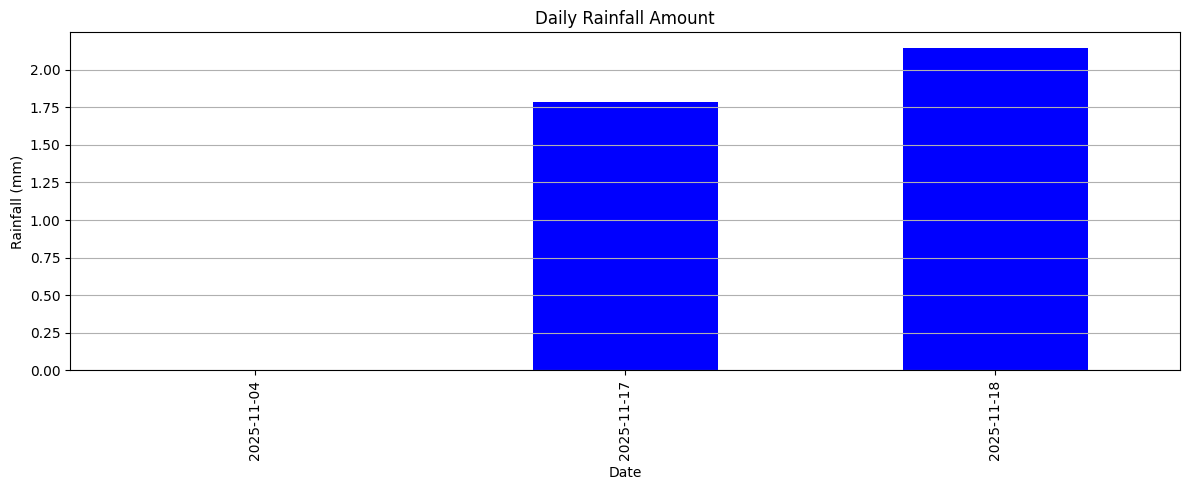

In [50]:

# สมมติ df_rain มี 'timestamp' และ 'rain_amount'

df_results['date'] = pd.to_datetime(df_results['Timestamp']).dt.date

# รวมปริมาณฝนรายวัน (sum)
rain_per_day = df_results.groupby('date')['rain'].mean()

# plot กราฟแท่งปริมาณฝนรายวัน
plt.figure(figsize=(12,5))
rain_per_day.plot(kind='bar', color='blue')

plt.title("Daily Rainfall Amount")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


KeyError: 'Temp'

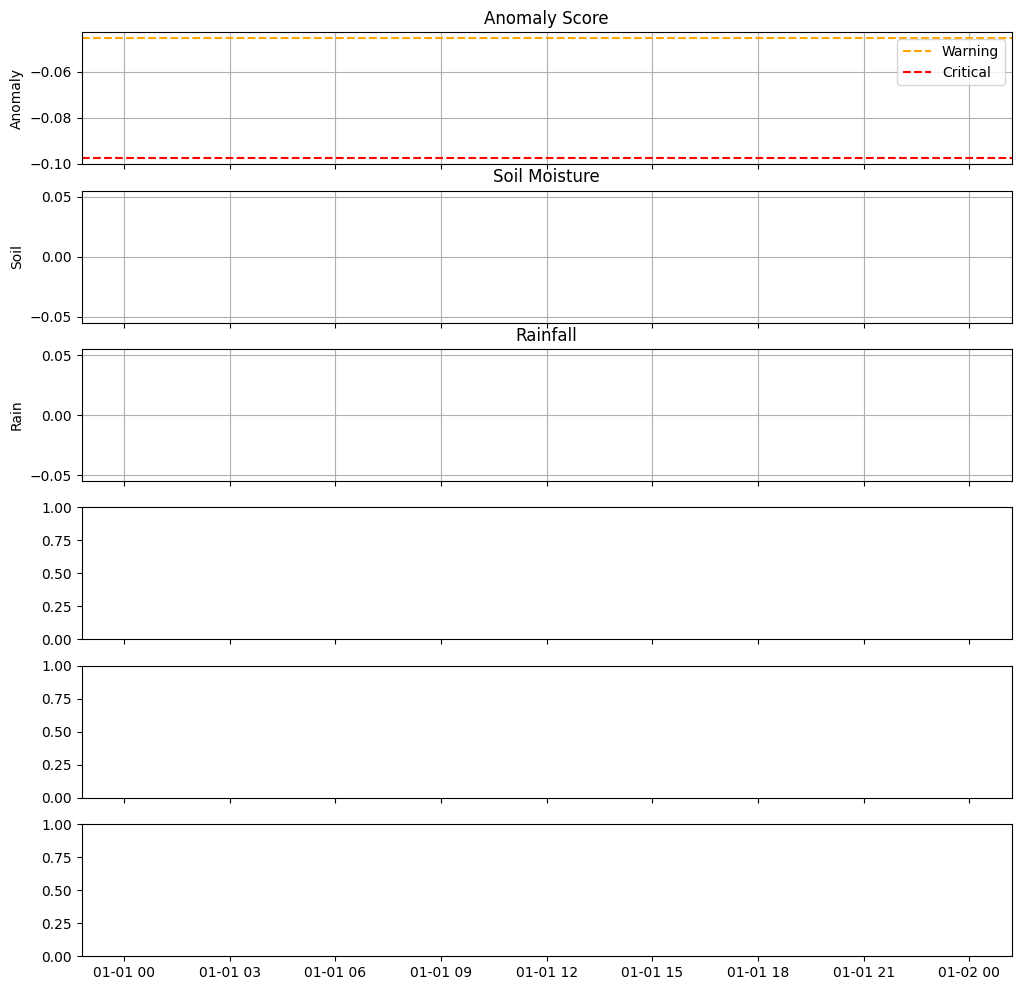

In [51]:
df_val['Timestamp'] = pd.to_datetime(df_val['Timestamp'])
df_dev = df_val.set_index('Timestamp').sort_index()
#df_dev = df_dev[df_dev['devID'] == 101.0]
df_range = df_dev.loc["2025-11-05":"2025-11-07"]

# สร้าง subplot 6 แถว
fig, axs = plt.subplots(6, 1, figsize=(12, 12), sharex=True)

# Plot 1: Anomaly Score
axs[0].scatter(df_range.index, df_range['anomaly_score'], color='green', s=15)
axs[0].axhline(y=warn_thresh, color='orange', linestyle='--', label='Warning')
axs[0].axhline(y=crit_thresh, color='red', linestyle='--', label='Critical')
axs[0].set_ylabel("Anomaly")
axs[0].set_title("Anomaly Score")
axs[0].legend()
axs[0].grid(True)

# Plot 2: Soil
axs[1].plot(df_range.index, df_range['soil'], color='saddlebrown')
axs[1].set_ylabel("Soil")
axs[1].set_title("Soil Moisture")
axs[1].grid(True)

# Plot 3: Rain
axs[2].plot(df_range.index, df_range['rain'], color='blue')
axs[2].set_ylabel("Rain")
axs[2].set_title("Rainfall")
axs[2].grid(True)

# Plot 4: Temp
axs[3].plot(df_range.index, df_range['Temp'], color='red')
axs[3].set_ylabel("Temp")
axs[3].set_title("Temperature")
axs[3].grid(True)

# Plot 5: Humi
axs[4].plot(df_range.index, df_range['hum'], color='purple')
axs[4].set_ylabel("Humi")
axs[4].set_title("Humidity")
axs[4].grid(True)

window_size = 20  # ลองปรับค่าตามความเหมาะสม เช่น 10, 50, 100
smoothed_geo = df_range['geo'].rolling(window=window_size).mean()

axs[5].plot(df_range.index, smoothed_geo, color='black')
axs[5].set_ylabel("Geo")
axs[5].set_title("Geophone (Smoothed)")
axs[5].grid(True)

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()


# F1-score

In [52]:
df_val["predicted_risk"].value_counts()

,count
predicted_risk,
Normal,1698
Critical,212
Warning,161


In [53]:
df_val["label"].value_counts()

,count
label,
critical,156
warning,125


In [54]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix

df_val["label"] = df_val["label"].fillna("Normal")

# 1.2 ปรับข้อความให้เป็นตัวพิมพ์เล็กทั้งหมด (Lowercase) เพื่อให้เทียบกันได้
# เช่น 'Normal' จะตรงกับ 'normal', 'Warning' ตรงกับ 'warning'
df_val["predicted_risk"] = df_val["predicted_risk"].str.lower().str.strip()
df_val["label"] = df_val["label"].str.lower().str.strip()

# ---------------------------------------------------------
# 2. คำนวณ F1 Score
# ---------------------------------------------------------

y_true = df_val["label"]          # ค่าจริง
y_pred = df_val["predicted_risk"] # ค่าที่โมเดลทำนาย

# กำหนดลำดับ Class เพื่อให้แสดงผลสวยงาม (เรียงตามความรุนแรง)
target_names = ['normal', 'warning', 'critical']

print("------- Classification Report (F1 Score) -------")
# คำสั่งนี้จะคำนวณ Precision, Recall, และ F1-score ให้ครบทุก Class
print(classification_report(y_true, y_pred, labels=target_names))

print("\n------- Confusion Matrix -------")
# ดูว่าทำนายถูก/ผิด ไปตกที่ช่องไหนบ้าง
cm = confusion_matrix(y_true, y_pred, labels=target_names)
df_cm = pd.DataFrame(cm, index=[f"Actual {c}" for c in target_names],
                         columns=[f"Pred {c}" for c in target_names])
print(df_cm)

# ---------------------------------------------------------
# 3. ถ้าต้องการค่า F1 Score ตัวเดียว (Macro หรือ Weighted)
# ---------------------------------------------------------
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"\nMacro F1 Score: {f1_macro:.4f}")

------- Classification Report (F1 Score) -------
              precision    recall  f1-score   support

      normal       1.00      0.95      0.97      1790
     warning       0.52      0.67      0.59       125
    critical       0.70      0.95      0.80       156

    accuracy                           0.93      2071
   macro avg       0.74      0.86      0.79      2071
weighted avg       0.95      0.93      0.94      2071


------- Confusion Matrix -------
                 Pred normal  Pred warning  Pred critical
Actual normal           1695            69             26
Actual warning             3            84             38
Actual critical            0             8            148

Macro F1 Score: 0.7879


In [55]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix

df_val["label"] = df_val["label"].fillna("Normal")

# 1.2 ปรับข้อความให้เป็นตัวพิมพ์เล็กทั้งหมด (Lowercase) เพื่อให้เทียบกันได้
# เช่น 'Normal' จะตรงกับ 'normal', 'Warning' ตรงกับ 'warning'
df_val["predicted_risk"] = df_val["predicted_risk"].str.lower().str.strip()
df_val["label"] = df_val["label"].str.lower().str.strip()

# ---------------------------------------------------------
# 2. คำนวณ F1 Score
# ---------------------------------------------------------

y_true = df_val["label"]          # ค่าจริง
y_pred = df_val["predicted_risk"] # ค่าที่โมเดลทำนาย

# กำหนดลำดับ Class เพื่อให้แสดงผลสวยงาม (เรียงตามความรุนแรง)
target_names = ['normal', 'warning', 'critical']

print("------- Classification Report (F1 Score) -------")
# คำสั่งนี้จะคำนวณ Precision, Recall, และ F1-score ให้ครบทุก Class
print(classification_report(y_true, y_pred, labels=target_names))

print("\n------- Confusion Matrix -------")
# ดูว่าทำนายถูก/ผิด ไปตกที่ช่องไหนบ้าง
cm = confusion_matrix(y_true, y_pred, labels=target_names)
df_cm = pd.DataFrame(cm, index=[f"Actual {c}" for c in target_names],
                         columns=[f"Pred {c}" for c in target_names])
print(df_cm)

# ---------------------------------------------------------
# 3. ถ้าต้องการค่า F1 Score ตัวเดียว (Macro หรือ Weighted)
# ---------------------------------------------------------
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"\nMacro F1 Score: {f1_macro:.4f}")

------- Classification Report (F1 Score) -------
              precision    recall  f1-score   support

      normal       1.00      0.95      0.97      1790
     warning       0.52      0.67      0.59       125
    critical       0.70      0.95      0.80       156

    accuracy                           0.93      2071
   macro avg       0.74      0.86      0.79      2071
weighted avg       0.95      0.93      0.94      2071


------- Confusion Matrix -------
                 Pred normal  Pred warning  Pred critical
Actual normal           1695            69             26
Actual warning             3            84             38
Actual critical            0             8            148

Macro F1 Score: 0.7879
